In [ ]:
# ДЗ
# 1. Подберите параметры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
import math

In [4]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [5]:
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])                                       
    if abs(av_val - img[point]) <= T:
        return True
    return False
    
def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i, j] == 0 and mask[i - r:i + r, j - r:j +
                r].sum() > 0:
                    if homo_fun(image, mask, (i, j), T):
                        local_mask[i, j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
    return mask * 255

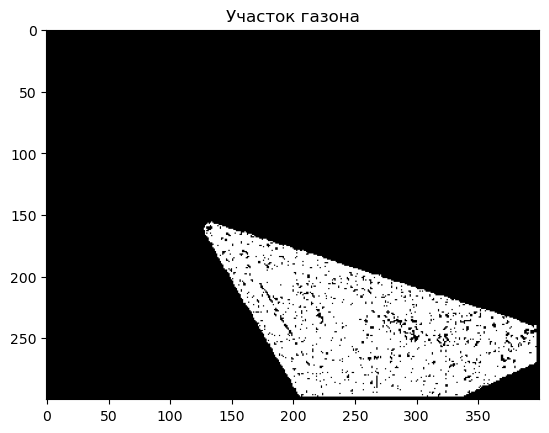

In [6]:
seed_point = (250, 250)
r = 2
T = 15

mask = region_growing(image_gray, seed_point, homo_average, r, T)

plt.imshow(mask, cmap="gray")
plt.title("Участок газона")
plt.show()

# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.

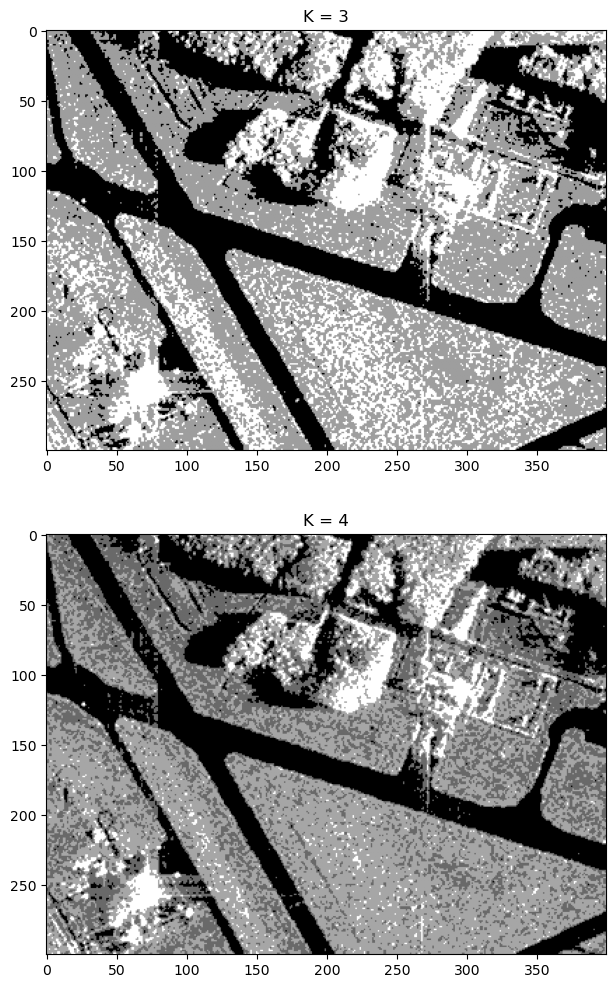

In [7]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

z = image_gray.reshape((-1, 1))
z = np.float32(z)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.1)
flags = cv2.KMEANS_PP_CENTERS  

K = 3
ret, label, center = cv2.kmeans(z, K, None, criteria, 10, flags)
center = np.uint8(center)
res = center[label.flatten()]
res2_k3 = res.reshape(image_gray.shape)

K = 4
ret, label, center = cv2.kmeans(z, K, None, criteria, 10, flags)
center = np.uint8(center)
res = center[label.flatten()]
res2_k4 = res.reshape(image_gray.shape)

plt.figure(figsize=(15, 12))
plt.subplot(2, 1, 1)
plt.imshow(res2_k3, cmap="gray")
plt.title("K = 3")

plt.subplot(2, 1, 2)
plt.imshow(res2_k4, cmap="gray")
plt.title("K = 4")

plt.show()


# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

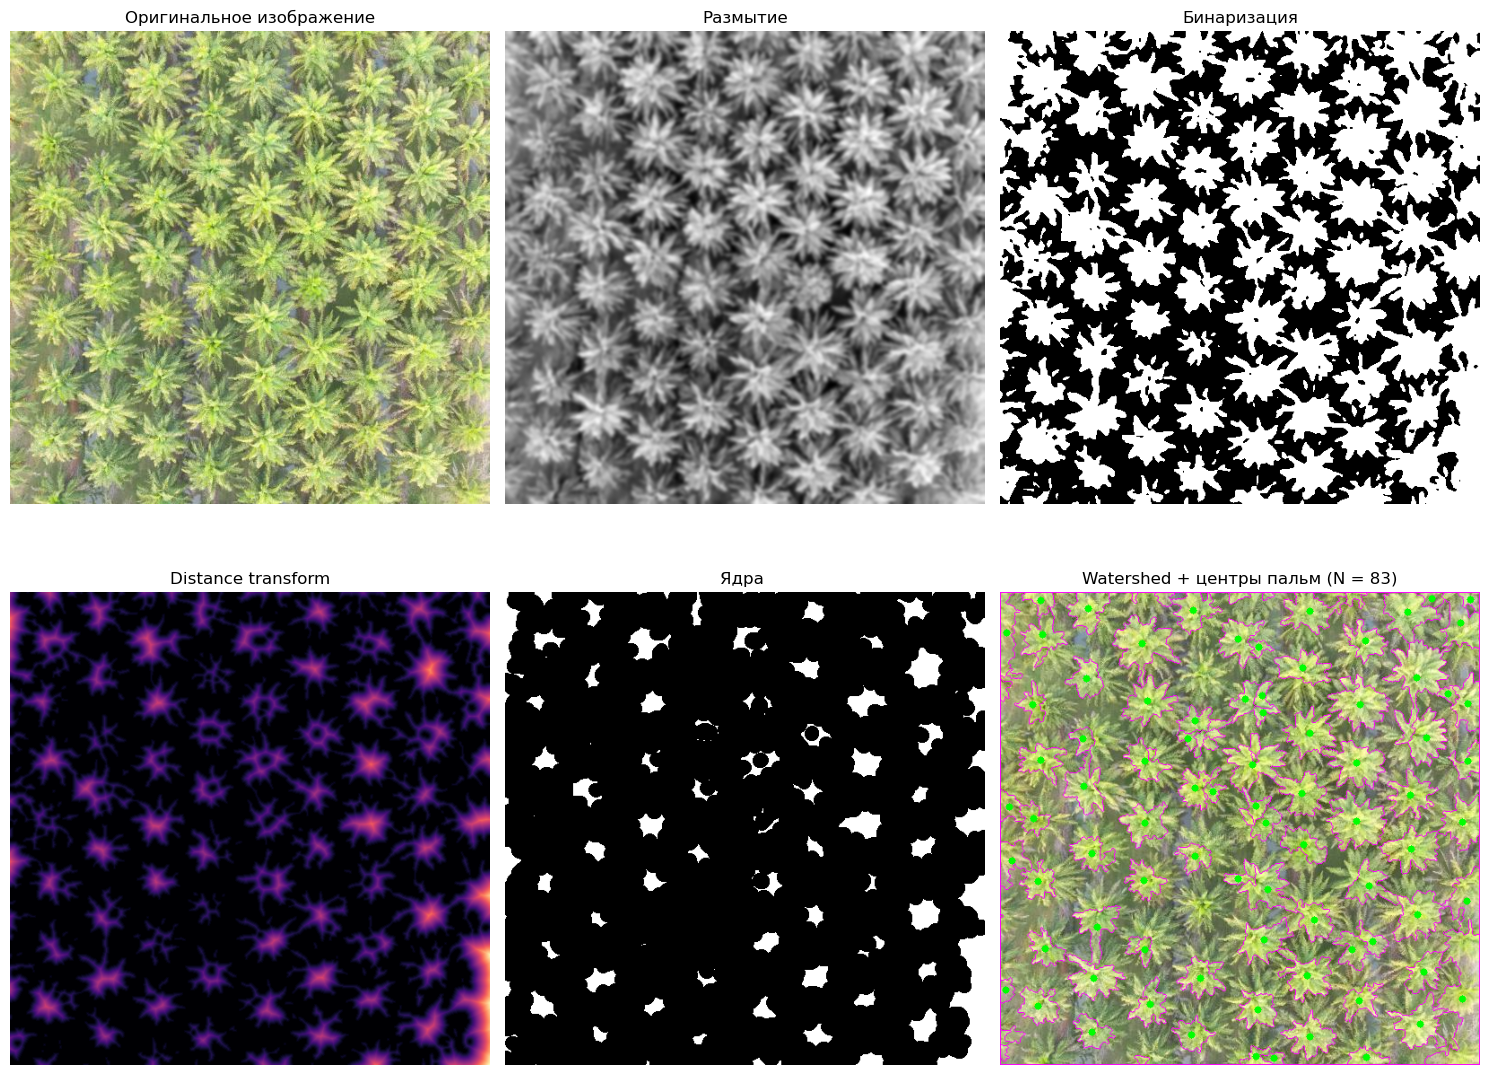

Количество пальм: 83


In [18]:

image = cv2.imread("palm_1.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(image_gray, (9, 9), 0)

_, thresh = cv2.threshold(
    blurred, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(
    dist_transform,
    0.25 * dist_transform.max(),   
    255,
    0
)
sure_fg = sure_fg.astype(np.uint8)

unknown = cv2.subtract(sure_bg, sure_fg)

ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

markers = cv2.watershed(image, markers)

segmented_image = image.copy()
segmented_image[markers == -1] = [255, 0, 255]  

num_palms = 0
centers_image = segmented_image.copy()
min_area = 200  

for label in np.unique(markers):
    if label <= 1:
        continue

    mask = (markers == label).astype(np.uint8)
    area = cv2.countNonZero(mask)
    if area < min_area:
        continue

    ys, xs = np.where(mask == 1)
    cx = int(xs.mean())
    cy = int(ys.mean())

    cv2.circle(centers_image, (cx, cy), 4, (0, 255, 0), -1)
    num_palms += 1

plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Оригинальное изображение")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Размытие")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(thresh, cmap="gray")
plt.title("Бинаризация")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(dist_transform, cmap="magma")
plt.title("Distance transform")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sure_fg, cmap="gray")
plt.title("Ядра ")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(centers_image, cv2.COLOR_BGR2RGB))
plt.title(f"Watershed + центры пальм (N = {num_palms})")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Количество пальм:", num_palms)